# Analyse Multi-Produits avec Dataset Enrichi - Clinique du Mont Vert
## IA Prédictive avec Prophet + Regressors Externes - Tous Produits

---

**Version ENRICHI - Analyse globale de tous les produits**

**Projet** : Master EISI - Gestion des stocks  
**Dataset** : Enrichi v3.0 - 5 ans de données (2020-2024)  
**Lignes** : 85,809 enregistrements  
**Produits** : 40 produits analysés simultanément  

---

## Différence avec le notebook mono-produit

Le notebook `Analyse_Mont_Vert_ENRICHI.ipynb` analyse **un seul produit** à la fois.  
Ce notebook entraîne un modèle Prophet **pour chaque produit** et produit :

- Un **tableau comparatif** des performances (MAE, MAPE, RMSE) de tous les produits
- Des **prédictions à 28 jours** pour chaque produit
- Une **recommandation de commande** par produit
- Un **plan d'arrivages** par produit
- Des **visualisations comparatives** globales
- Un **export consolidé** (CSV + JSON) de tous les résultats

---

## Régresseurs Externes
- **temperature** : Température extérieure (°C)
- **taux_occupation** : Taux d'occupation hôpital (%)
- **nb_patients** : Nombre de patients
- **epidemie_grippe** : Périodes d'épidémie (0/1)
- **jour_ferie** : Jours fériés français (0/1)
- **covid_impact** : Périodes COVID (0/1)

# Étape 1 : Imports et Configuration

In [1]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
from pathlib import Path
warnings.filterwarnings('ignore')

# Configuration pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10

print(" Imports de base terminés !")

 Imports de base terminés !


In [2]:
# Import Prophet et utilitaires
print(" Import de Prophet...")
try:
    from prophet import Prophet
    from prophet.plot import plot_yearly, plot_weekly, add_changepoints_to_plot
    from prophet.utilities import regressor_coefficients
    print(" Prophet importé avec succès !")
    PROPHET_AVAILABLE = True
except Exception as e:
    print(f"  Erreur Prophet : {e}")
    print("  Installation : pip install prophet")
    PROPHET_AVAILABLE = False

Importing plotly failed. Interactive plots will not work.


 Import de Prophet...
 Prophet importé avec succès !


In [3]:
# Import Results Manager (optionnel)
try:
    from results_manager import ResultsManager
    results_mgr = ResultsManager()
    results_mgr.create_run_directory()
    print(f" Results Manager activé")
    print(f" Résultats seront sauvegardés dans : {results_mgr.get_run_path()}")
    USE_RESULTS_MANAGER = True
except:
    print(" Results Manager non disponible (optionnel)")
    USE_RESULTS_MANAGER = False

📁 Dossier de résultats créé : ..\results\20260315_163328
 Results Manager activé
 Résultats seront sauvegardés dans : ..\results\20260315_163328


In [4]:
# Configuration MLflow (optionnel)
import sys
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MLFLOW_EXPERIMENT = 'prophet-notebook-enrichi'
MLFLOW_AVAILABLE = False
MLFLOW_IMPORT_ERROR = None

try:
    import mlflow
    import src.mlflow_utils as mlflow_utils
    from src.model import model_summary

    mlflow_utils = importlib.reload(mlflow_utils)

    check_mlflow_available = mlflow_utils.check_mlflow_available
    get_default_tracking_uri = mlflow_utils.get_default_tracking_uri
    log_prediction_run = mlflow_utils.log_prediction_run

    MLFLOW_TRACKING_URI = get_default_tracking_uri(PROJECT_ROOT)
    MLFLOW_AVAILABLE = check_mlflow_available()

    print(f' Python actif : {sys.executable}')
    print(f' Module MLflow utils : {mlflow_utils.__file__}')

    if MLFLOW_AVAILABLE:
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        print(' MLflow disponible')
        print(f' Backend SQLite : {MLFLOW_TRACKING_URI}')
        print(f' Expérience par défaut : {MLFLOW_EXPERIMENT}')
    else:
        print(' MLflow non disponible dans cet environnement')
except Exception as e:
    MLFLOW_IMPORT_ERROR = str(e)
    print(f' MLflow non chargé : {e}')
    MLFLOW_AVAILABLE = False
    MLFLOW_TRACKING_URI = None

 Python actif : c:\Users\mxmle\project\final-project\venv\Scripts\python.exe
 Module MLflow utils : C:\Users\mxmle\project\final-project\src\mlflow_utils.py
 MLflow disponible
 Backend SQLite : sqlite:///C:/Users/mxmle/project/final-project/mlflow.db
 Expérience par défaut : prophet-notebook-enrichi


# Étape 2 : Chargement du Dataset Enrichi

In [5]:
# Chemin du dataset enrichi
FICHIER_CSV = "../data/dataset_stock_hopital_ENRICHI.csv"

if not Path(FICHIER_CSV).exists():
    print(f" Fichier introuvable : {FICHIER_CSV}")

df = pd.read_csv(FICHIER_CSV)
df['date'] = pd.to_datetime(df['date'])
df['date_expiration'] = pd.to_datetime(df['date_expiration'])

print(f" Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f" Période couverte : {df['date'].min().date()} → {df['date'].max().date()}")
print(f" Durée totale : {(df['date'].max() - df['date'].min()).days / 365:.1f} ans")

 Dimensions : 85,809 lignes × 22 colonnes
 Taille mémoire : 39.98 MB
 Période couverte : 2020-01-01 → 2024-12-31
 Durée totale : 5.0 ans


In [6]:
# Filtrer uniquement les produits alimentaires (exclure les produits d'entretien)
df = df[df['type_produit'] == 'Aliment'].copy()
produits = sorted(df['nom_produit'].unique())
print(f" {len(produits)} produits alimentaires retenus pour l'analyse :")
print("="*70)
for i, p in enumerate(produits, 1):
    nb = len(df[(df['nom_produit'] == p) & (df['type_sortie'] == 'CONSOMMATION')])
    print(f"   {i:2d}. {p:<25s} ({nb:,} sorties de consommation)")

 35 produits alimentaires retenus pour l'analyse :
    1. Beurre                    (1,749 sorties de consommation)
    2. Biscuits                  (1,631 sorties de consommation)
    3. Café                      (1,590 sorties de consommation)
    4. Carottes                  (1,654 sorties de consommation)
    5. Compote de fruits         (1,626 sorties de consommation)
    6. Confiture                 (1,583 sorties de consommation)
    7. Conserves légumes         (1,720 sorties de consommation)
    8. Crème fraîche             (1,912 sorties de consommation)
    9. Farine                    (1,738 sorties de consommation)
   10. Fromage emmental          (1,784 sorties de consommation)
   11. Fromage frais             (1,913 sorties de consommation)
   12. Fruits frais              (1,301 sorties de consommation)
   13. Huile végétale            (1,731 sorties de consommation)
   14. Jambon blanc              (1,471 sorties de consommation)
   15. Jus d'orange              (1,502

# Étape 3 : Préparation des Données Globales

In [7]:
# Statistiques sur les régresseurs (identiques pour tous les produits)
print(" STATISTIQUES DES RÉGRESSEURS")
print("="*70)

stats_journalieres = df.groupby('date').agg({
    'temperature': 'mean',
    'taux_occupation': 'mean',
    'nb_patients': 'mean',
    'epidemie_grippe': 'max',
    'jour_ferie': 'max',
    'covid_impact': 'max'
}).reset_index()

print(f"\n  Température : {stats_journalieres['temperature'].mean():.1f}°C (min {stats_journalieres['temperature'].min():.1f}, max {stats_journalieres['temperature'].max():.1f})")
print(f" Taux d'occupation : {stats_journalieres['taux_occupation'].mean():.1f}% (min {stats_journalieres['taux_occupation'].min():.1f}%, max {stats_journalieres['taux_occupation'].max():.1f}%)")
print(f" Nombre de patients : {stats_journalieres['nb_patients'].mean():.0f}/jour (min {stats_journalieres['nb_patients'].min():.0f}, max {stats_journalieres['nb_patients'].max():.0f})")

nb_jours_grippe = int(stats_journalieres['epidemie_grippe'].sum())
nb_jours_feries = int(stats_journalieres['jour_ferie'].sum())
nb_jours_covid = int(stats_journalieres['covid_impact'].sum())
nb_jours_total = len(stats_journalieres)

print(f" Épidémies grippe : {nb_jours_grippe} jours ({nb_jours_grippe/nb_jours_total*100:.1f}%)")
print(f" Jours fériés     : {nb_jours_feries} jours")
print(f" Impact COVID     : {nb_jours_covid} jours ({nb_jours_covid/nb_jours_total*100:.1f}%)")

 STATISTIQUES DES RÉGRESSEURS

  Température : 14.9°C (min -5.3, max 35.4)
 Taux d'occupation : 76.9% (min 50.9%, max 100.0%)
 Nombre de patients : 191/jour (min 128, max 258)
 Épidémies grippe : 181 jours (9.9%)
 Jours fériés     : 40 jours
 Impact COVID     : 230 jours (12.6%)


In [8]:
# Configuration des holidays (commune à tous les produits)
daily_global = stats_journalieres.copy()

holidays_jf = daily_global[daily_global['jour_ferie'] == 1][['date']].drop_duplicates()
holidays_jf.columns = ['ds']
holidays_jf['holiday'] = 'jour_ferie'
holidays_jf['lower_window'] = 0
holidays_jf['upper_window'] = 0

holidays_covid = daily_global[daily_global['covid_impact'] == 1][['date']].drop_duplicates()
holidays_covid.columns = ['ds']
holidays_covid['holiday'] = 'covid_19'
holidays_covid['lower_window'] = 0
holidays_covid['upper_window'] = 0

holidays = pd.concat([holidays_jf, holidays_covid])
print(f" Holidays configurés : {len(holidays)} jours (jours fériés : {len(holidays_jf)}, COVID : {len(holidays_covid)})")

# Changepoints manuels communs
changepoints_manuels = [
    '2020-03-15',  # COVID-19 Vague 1
    '2020-11-01',  # COVID-19 Vague 2
    '2021-05-01',  # Déconfinement
    '2022-01-01',  # Nouvelle Direction
    '2023-09-01'   # Extension Hôpital
]
print(f" Changepoints manuels : {len(changepoints_manuels)} événements")

 Holidays configurés : 270 jours (jours fériés : 40, COVID : 230)
 Changepoints manuels : 5 événements


# Étape 4 : Entraînement Prophet pour Chaque Produit

Pour chaque produit, nous allons :
1. Filtrer les données de consommation
2. Agréger par jour avec les régresseurs
3. Split train/test (dernière année = test)
4. Entraîner un modèle Prophet avec regressors
5. Évaluer (MAE, MAPE, RMSE)
6. Réentraîner sur toutes les données
7. Prédire 28 jours futurs
8. Générer la recommandation de commande et le plan d'arrivages

In [9]:
# Import des fonctions d'arrivages
import src.enriched_pipeline as enriched_pipeline
enriched_pipeline = importlib.reload(enriched_pipeline)
build_dlc_arrival_schedule = enriched_pipeline.build_dlc_arrival_schedule
infer_product_dlc_days = enriched_pipeline.infer_product_dlc_days

print(" Fonctions d'arrivages importées")

 Fonctions d'arrivages importées


In [10]:
# =====================================================================
# BOUCLE PRINCIPALE : Entraînement et prédiction pour chaque produit
# =====================================================================

HORIZON_PREVISION = 28        # jours de prédiction future
HORIZON_COMMANDE_JOURS = 7    # jours pour la recommandation de commande
COUVERTURE_SECURITE_JOURS = 2 # jours de stock de sécurité

# MCMC : active le sampling bayésien pour obtenir de vrais intervalles
# de confiance sur les coefficients des régresseurs.
# Mettre à 0 pour désactiver (estimation MAP uniquement, plus rapide).
MCMC_SAMPLES = 300

# Stockage des résultats
all_metrics = []              # Métriques de performance par produit
all_predictions = []          # Prédictions futures par produit
all_recommendations = []      # Recommandations de commande par produit
all_arrivages = []            # Plans d'arrivages par produit
all_coefficients = []         # Coefficients des régresseurs par produit
product_models = {}           # Modèles finaux par produit
product_forecasts = {}        # Forecasts complets par produit
skipped_products = []         # Produits ignorés (pas assez de données)

print(f" ENTRAÎNEMENT MULTI-PRODUITS")
print(f" {len(produits)} produits à analyser")
if MCMC_SAMPLES > 0:
    print(f" MCMC activé ({MCMC_SAMPLES} samples) → intervalles de confiance sur les coefficients")
else:
    print(f" MCMC désactivé → estimation MAP (pas d'intervalles sur les coefficients)")
print("="*70)

for idx, produit_name in enumerate(produits, 1):
    print(f"\n{'─'*70}")
    print(f" [{idx}/{len(produits)}] {produit_name}")
    print(f"{'─'*70}")

    # --- 1. Filtrer les sorties de consommation ---
    produit_df = df[
        (df['nom_produit'] == produit_name) &
        (df['type_sortie'] == 'CONSOMMATION')
    ].copy()

    if len(produit_df) < 30:
        print(f"   Ignoré : seulement {len(produit_df)} sorties (min 30)")
        skipped_products.append({'produit': produit_name, 'raison': f'{len(produit_df)} sorties'})
        continue

    print(f"   {len(produit_df):,} sorties | "
          f"{produit_df['date'].min().date()} → {produit_df['date'].max().date()} | "
          f"{produit_df['quantite'].sum():,.1f} {produit_df['unite'].iloc[0]}")

    # --- 2. Agrégation quotidienne avec régresseurs ---
    daily = produit_df.groupby('date').agg({
        'quantite': 'sum',
        'temperature': 'mean',
        'taux_occupation': 'mean',
        'nb_patients': 'mean',
        'epidemie_grippe': 'max',
        'jour_ferie': 'max',
        'covid_impact': 'max'
    }).reset_index()

    date_range = pd.date_range(start=daily['date'].min(), end=daily['date'].max(), freq='D')
    full_dates = pd.DataFrame({'date': date_range})
    daily = full_dates.merge(daily, on='date', how='left')
    daily['quantite'].fillna(0, inplace=True)
    for col in ['temperature', 'taux_occupation', 'nb_patients']:
        daily[col].fillna(daily[col].mean(), inplace=True)
    for col in ['epidemie_grippe', 'jour_ferie', 'covid_impact']:
        daily[col].fillna(0, inplace=True)

    prophet_df = daily.rename(columns={'date': 'ds', 'quantite': 'y'})

    # --- 3. Split train/test ---
    split_date = prophet_df['ds'].max() - pd.Timedelta(days=365)
    train = prophet_df[prophet_df['ds'] <= split_date].copy()
    test = prophet_df[prophet_df['ds'] > split_date].copy()

    if len(train) < 30 or len(test) < 10:
        print(f"   Ignoré : split insuffisant (train={len(train)}, test={len(test)})")
        skipped_products.append({'produit': produit_name, 'raison': f'train={len(train)}, test={len(test)}'})
        continue

    # --- 4. Entraîner un modèle Prophet (évaluation) avec MCMC pour les coefficients ---
    model_eval = Prophet(
        holidays=holidays,
        holidays_prior_scale=10.0,
        yearly_seasonality=20,
        weekly_seasonality=5,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        seasonality_prior_scale=10.0,
        changepoints=changepoints_manuels,
        changepoint_prior_scale=0.5,
        changepoint_range=0.9,
        interval_width=0.85,
        growth='linear',
        mcmc_samples=MCMC_SAMPLES,
    )
    model_eval.add_regressor('temperature', prior_scale=0.5, standardize=True, mode='additive')
    model_eval.add_regressor('taux_occupation', prior_scale=1.0, standardize=True, mode='additive')
    model_eval.add_regressor('nb_patients', prior_scale=0.5, standardize=True, mode='additive')
    model_eval.add_regressor('epidemie_grippe', prior_scale=0.5, standardize=False, mode='additive')
    model_eval.fit(train)

    # --- 5. Évaluation sur le test ---
    preds_test = model_eval.predict(test)
    y_true = test['y'].values
    y_pred = preds_test['yhat'].values

    mae = np.mean(np.abs(y_true - y_pred))
    mask_nz = y_true > 0
    mape = (np.mean(np.abs((y_true[mask_nz] - y_pred[mask_nz]) / y_true[mask_nz])) * 100) if mask_nz.sum() > 0 else float('inf')
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1 - (ss_res / ss_tot)) if ss_tot != 0 else 0.0

    print(f"   Évaluation → MAE={mae:.2f}  MAPE={mape:.1f}%  RMSE={rmse:.2f}  R²={r2:.3f}")

    # Coefficients des régresseurs (avec intervalles MCMC si activé)
    try:
        coeffs = regressor_coefficients(model_eval)
        coeffs['produit'] = produit_name
        all_coefficients.append(coeffs)
        if MCMC_SAMPLES > 0:
            for _, row in coeffs.iterrows():
                print(f"   Coeff {row['regressor']}: {row['coef']:.4f} [{row['coef_lower']:.4f}, {row['coef_upper']:.4f}]")
    except:
        pass

    # --- 6. Réentraîner sur toutes les données (MAP pour rapidité) ---
    model_final = Prophet(
        holidays=holidays,
        holidays_prior_scale=10.0,
        yearly_seasonality=20,
        weekly_seasonality=5,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        seasonality_prior_scale=10.0,
        changepoints=changepoints_manuels,
        changepoint_prior_scale=0.5,
        changepoint_range=0.9,
        interval_width=0.85,
        growth='linear'
    )
    model_final.add_regressor('temperature', prior_scale=0.5, standardize=True, mode='additive')
    model_final.add_regressor('taux_occupation', prior_scale=1.0, standardize=True, mode='additive')
    model_final.add_regressor('nb_patients', prior_scale=0.5, standardize=True, mode='additive')
    model_final.add_regressor('epidemie_grippe', prior_scale=0.5, standardize=False, mode='additive')
    model_final.fit(prophet_df)

    # --- 7. Prédictions futures ---
    future = model_final.make_future_dataframe(periods=HORIZON_PREVISION)
    future = future.merge(
        prophet_df[['ds', 'temperature', 'taux_occupation', 'nb_patients', 'epidemie_grippe']],
        on='ds', how='left'
    )
    for col in ['temperature', 'taux_occupation', 'nb_patients']:
        future[col].fillna(prophet_df[col].mean(), inplace=True)
    future['epidemie_grippe'].fillna(
        future['ds'].dt.month.isin([1, 2, 3]).astype(int), inplace=True
    )

    forecast = model_final.predict(future)
    predictions_futures = forecast[forecast['ds'] > prophet_df['ds'].max()].copy()

    product_models[produit_name] = model_final
    product_forecasts[produit_name] = forecast

    print(f"   Prédictions 28j → total={predictions_futures['yhat'].sum():.1f}  moy/j={predictions_futures['yhat'].mean():.2f}")

    # Stocker les prédictions
    pred_export = predictions_futures[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    pred_export['produit'] = produit_name
    all_predictions.append(pred_export)

    # --- 8. Recommandation de commande ---
    date_debut_prevision = predictions_futures['ds'].min().normalize()
    stock_snapshot = produit_df[produit_df['date'] == produit_df['date'].max()].copy()
    stock_disponible = stock_snapshot.loc[
        stock_snapshot['date_expiration'] >= date_debut_prevision,
        'stock_theorique'
    ].sum()

    preds_cmd = predictions_futures.head(HORIZON_COMMANDE_JOURS).copy()
    preds_cmd['yhat'] = preds_cmd['yhat'].clip(lower=0)
    preds_cmd['yhat_upper'] = preds_cmd['yhat_upper'].clip(lower=0)

    conso_prevue = preds_cmd['yhat'].sum()
    stock_securite = preds_cmd['yhat'].mean() * COUVERTURE_SECURITE_JOURS
    qte_commander = max(conso_prevue + stock_securite - stock_disponible, 0)
    couverture_j = (stock_disponible / preds_cmd['yhat'].mean()) if preds_cmd['yhat'].mean() > 0 else float('inf')

    # Plan d'arrivages
    try:
        dlc_jours = infer_product_dlc_days(produit_df, product_name=produit_name)
        plan_arrivages = build_dlc_arrival_schedule(
            produit_df=produit_df,
            predictions_futures=predictions_futures,
            product_name=produit_name,
            dlc_days=dlc_jours,
        )
        plan_arrivages['produit'] = produit_name
        all_arrivages.append(plan_arrivages)
        nb_arrivages = len(plan_arrivages)
        qte_arrivages_total = plan_arrivages['quantity_to_order'].sum()
    except Exception as e:
        dlc_jours = None
        nb_arrivages = 0
        qte_arrivages_total = 0

    # Stocker les métriques et recommandations
    all_metrics.append({
        'produit': produit_name,
        'type_produit': produit_df['type_produit'].iloc[0],
        'unite': produit_df['unite'].iloc[0],
        'nb_sorties': len(produit_df),
        'nb_jours_data': len(prophet_df),
        'MAE': round(mae, 2),
        'MAPE': round(mape, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 3),
        'total_prevu_28j': round(predictions_futures['yhat'].sum(), 2),
        'moy_jour_prevu': round(predictions_futures['yhat'].mean(), 2),
    })

    all_recommendations.append({
        'produit': produit_name,
        'stock_disponible': round(stock_disponible, 2),
        'consommation_prevue_7j': round(conso_prevue, 2),
        'stock_securite': round(stock_securite, 2),
        'quantite_a_commander': round(qte_commander, 2),
        'couverture_estimee_jours': round(couverture_j, 1) if np.isfinite(couverture_j) else None,
        'dlc_jours': dlc_jours,
        'nb_arrivages_28j': nb_arrivages,
        'qte_arrivages_total_28j': round(qte_arrivages_total, 2),
    })

    # --- MLflow tracking (optionnel) ---
    if MLFLOW_AVAILABLE:
        try:
            tracked_model_summary = model_summary(model_final)
            test_preds_mlflow = preds_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
            future_preds_mlflow = predictions_futures[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

            produit_slug = produit_name.lower().replace(' ', '_').replace('é', 'e').replace('è', 'e').replace('ê', 'e').replace('î', 'i').replace('ô', 'o')
            notebook_tags = {
                'source': 'notebook',
                'notebook_name': 'Analyse_Tous_Produits_ENRICHI.ipynb',
                'analysis_type': 'enriched-multi-product',
                'product_slug': produit_slug,
            }

            log_prediction_run(
                product_name=produit_name,
                dataset_name='enriched',
                horizon_days=HORIZON_PREVISION,
                dataset_path=(PROJECT_ROOT / 'data' / Path(FICHIER_CSV).name).resolve(),
                train_df=train, test_df=test,
                test_predictions=test_preds_mlflow,
                future_predictions=future_preds_mlflow,
                metrics={'mae': float(mae), 'mape': float(mape), 'rmse': float(rmse), 'r2': r2},
                prophet_settings={
                    'seasonality_mode': tracked_model_summary.get('seasonality_mode'),
                    'changepoint_prior_scale': tracked_model_summary.get('changepoint_prior_scale'),
                    'interval_width': tracked_model_summary.get('interval_width'),
                    'daily_seasonality': tracked_model_summary.get('daily_seasonality'),
                    'weekly_seasonality': tracked_model_summary.get('weekly_seasonality'),
                    'yearly_seasonality': tracked_model_summary.get('yearly_seasonality'),
                    'regressors': tracked_model_summary.get('regressors', []),
                    'holidays': ['jour_ferie', 'covid_19'],
                    'manual_changepoints': changepoints_manuels,
                },
                model_details=tracked_model_summary,
                experiment_name=MLFLOW_EXPERIMENT,
                tracking_uri=MLFLOW_TRACKING_URI,
                model=model_final,
                run_tags=notebook_tags,
            )
        except Exception as e:
            print(f"   MLflow : {e}")

print("\n" + "="*70)
print(f" ENTRAÎNEMENT TERMINÉ")
print(f" {len(all_metrics)} produits analysés | {len(skipped_products)} ignorés")
print("="*70)

 ENTRAÎNEMENT MULTI-PRODUITS
 35 produits à analyser
 MCMC activé (300 samples) → intervalles de confiance sur les coefficients

──────────────────────────────────────────────────────────────────────
 [1/35] Beurre
──────────────────────────────────────────────────────────────────────
   1,749 sorties | 2020-01-08 → 2024-12-31 | 6,839.7 kg


16:33:29 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

...

16:50:31 - cmdstanpy - INFO - Chain [1] start processing


   Évaluation → MAE=3.54  MAPE=25.1%  RMSE=4.71  R²=0.156
   Coeff temperature: 0.0479 [-0.0031, 0.0924]
   Coeff taux_occupation: 0.1945 [0.0849, 0.3008]
   Coeff nb_patients: -0.0125 [-0.0520, 0.0287]
   Coeff epidemie_grippe: 4.8200 [3.9763, 5.7262]


16:50:31 - cmdstanpy - INFO - Chain [1] done processing


   Prédictions 28j → total=384.7  moy/j=13.74



 ENTRAÎNEMENT TERMINÉ
 35 produits analysés | 0 ignorés


# Étape 5 : Tableau Comparatif des Performances

In [11]:
# Tableau comparatif des métriques pour tous les produits
metrics_df = pd.DataFrame(all_metrics).sort_values('MAPE')

print(" TABLEAU COMPARATIF DES PERFORMANCES")
print("="*70)
print(f" {len(metrics_df)} produits analysés\n")

display(metrics_df.style.format({
    'MAE': '{:.2f}',
    'MAPE': '{:.1f}%',
    'RMSE': '{:.2f}',
    'R2': '{:.3f}',
    'total_prevu_28j': '{:.1f}',
    'moy_jour_prevu': '{:.2f}',
}).background_gradient(subset=['MAPE'], cmap='RdYlGn_r'))

print(f"\n STATISTIQUES GLOBALES")
print(f"   MAPE moyen     : {metrics_df['MAPE'].mean():.1f}%")
print(f"   MAPE médian    : {metrics_df['MAPE'].median():.1f}%")
print(f"   Meilleur MAPE  : {metrics_df.iloc[0]['produit']} ({metrics_df.iloc[0]['MAPE']:.1f}%)")
print(f"   Pire MAPE      : {metrics_df.iloc[-1]['produit']} ({metrics_df.iloc[-1]['MAPE']:.1f}%)")
print(f"   Produits < 20% MAPE : {(metrics_df['MAPE'] < 20).sum()}/{len(metrics_df)}")

if skipped_products:
    print(f"\n Produits ignorés ({len(skipped_products)}) :")
    for s in skipped_products:
        print(f"   - {s['produit']} ({s['raison']})")

 TABLEAU COMPARATIF DES PERFORMANCES
 35 produits analysés



,produit,type_produit,unite,nb_sorties,nb_jours_data,MAE,MAPE,RMSE,R2,total_prevu_28j,moy_jour_prevu
17,Oeufs,Aliment,unité,1730,1820,16.73,18.7%,23.34,0.473,2204.7,78.74
21,Poulet frais,Aliment,kg,1614,1826,3.67,18.8%,5.18,0.149,395.9,14.14
13,Jambon blanc,Aliment,kg,1471,1820,2.01,19.3%,2.78,0.345,253.1,9.04
9,Fromage emmental,Aliment,kg,1784,1820,1.30,19.7%,1.83,0.458,165.4,5.91
20,Pommes de terre,Aliment,kg,1680,1820,4.40,19.9%,5.83,0.432,544.1,19.43
32,Viande de boeuf,Aliment,kg,1497,1824,2.53,20.0%,3.51,0.318,328.1,11.72
25,Salade verte,Aliment,kg,1560,1826,2.83,20.4%,3.86,0.261,336.3,12.01
6,Conserves légumes,Aliment,kg,1720,1813,2.05,21.1%,2.87,0.377,270.1,9.65
15,Lait entier,Aliment,L,1848,1822,10.41,21.2%,15.02,0.013,1074.0,38.36
0,Beurre,Aliment,kg,1749,1820,1.20,21.6%,1.69,0.341,137.9,4.92



 STATISTIQUES GLOBALES
   MAPE moyen     : 29.6%
   MAPE médian    : 25.5%
   Meilleur MAPE  : Oeufs (18.7%)
   Pire MAPE      : Thé (53.9%)
   Produits < 20% MAPE : 6/35


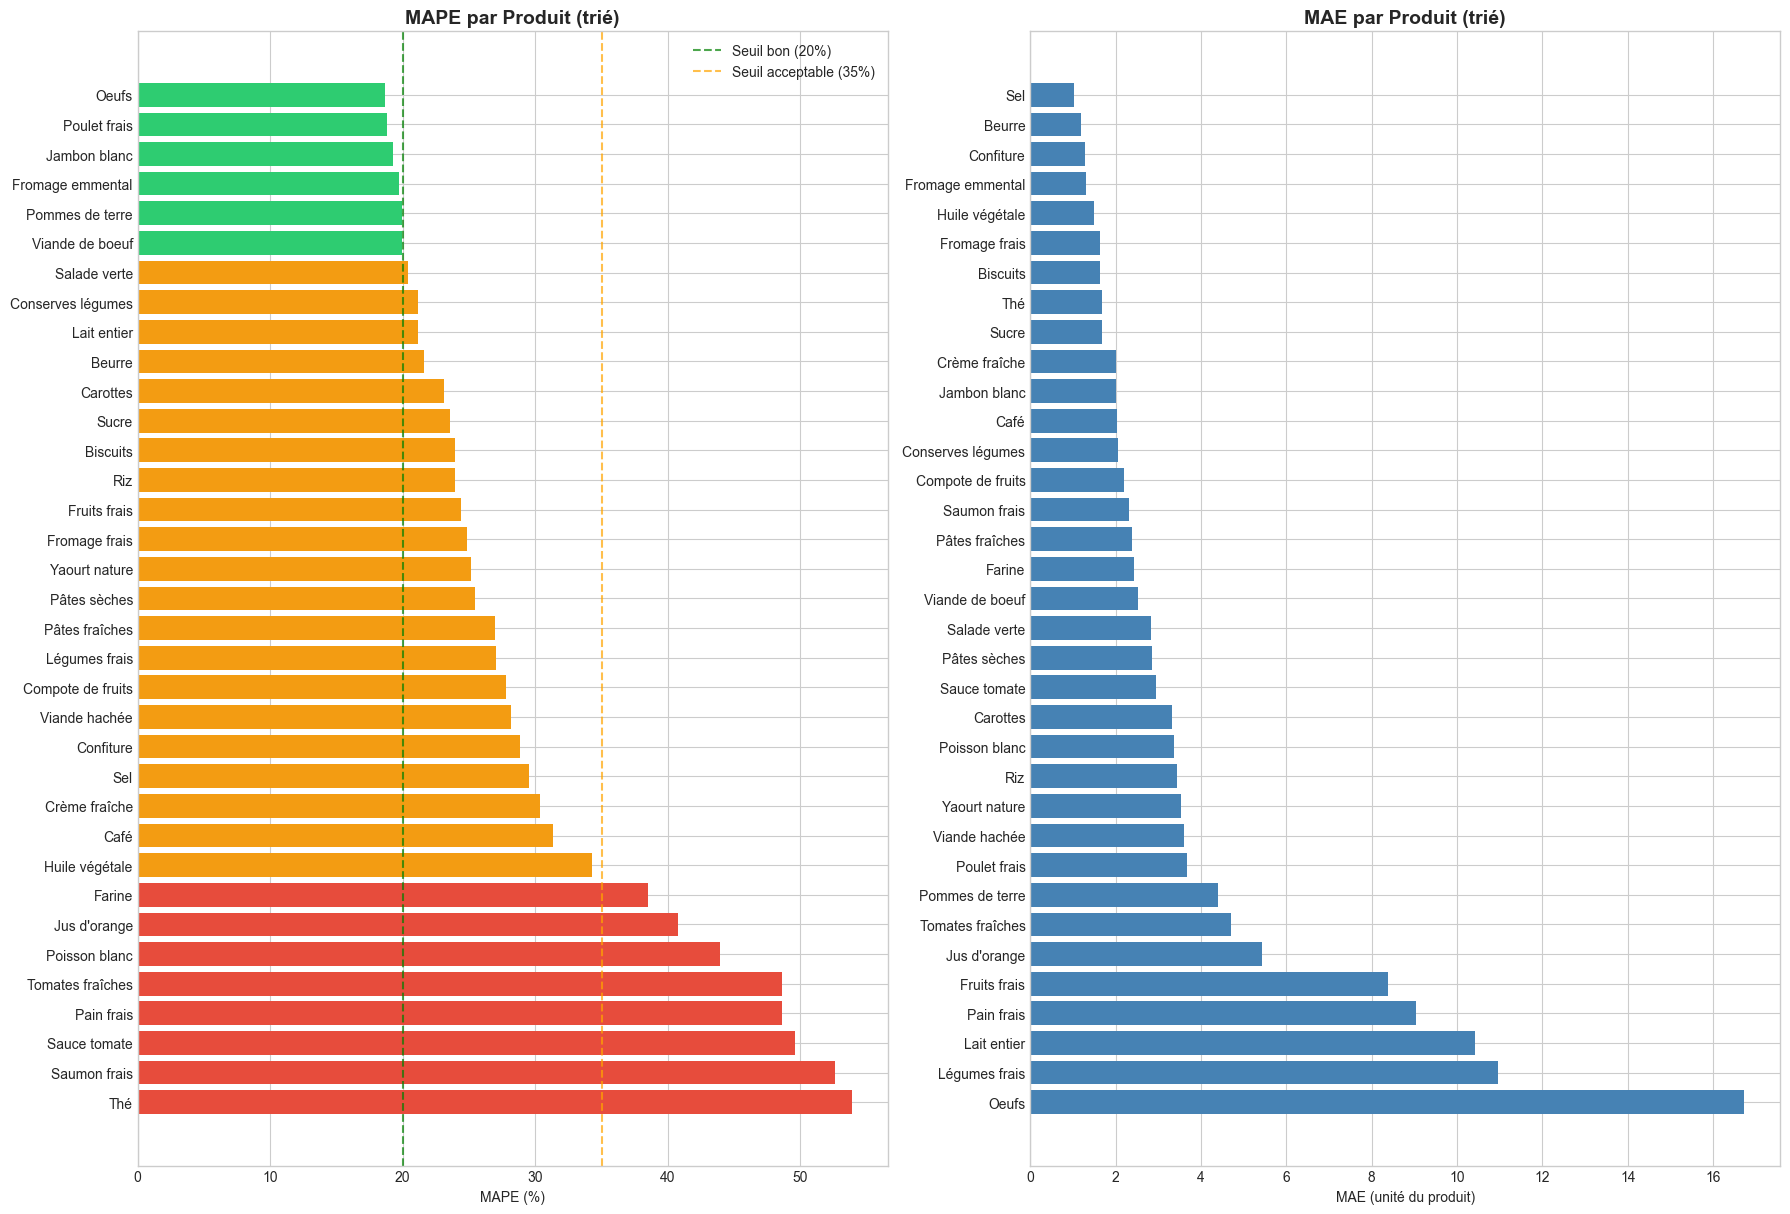

In [12]:
# Visualisation des MAPE par produit
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(metrics_df) * 0.35)))

# Graphique 1 : MAPE par produit
colors = ['#2ecc71' if x < 20 else '#f39c12' if x < 35 else '#e74c3c' for x in metrics_df['MAPE']]
axes[0].barh(metrics_df['produit'], metrics_df['MAPE'], color=colors)
axes[0].axvline(x=20, color='green', linestyle='--', alpha=0.7, label='Seuil bon (20%)')
axes[0].axvline(x=35, color='orange', linestyle='--', alpha=0.7, label='Seuil acceptable (35%)')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('MAPE par Produit (trié)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# Graphique 2 : MAE par produit
metrics_sorted_mae = metrics_df.sort_values('MAE')
axes[1].barh(metrics_sorted_mae['produit'], metrics_sorted_mae['MAE'], color='steelblue')
axes[1].set_xlabel('MAE (unité du produit)')
axes[1].set_title('MAE par Produit (trié)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

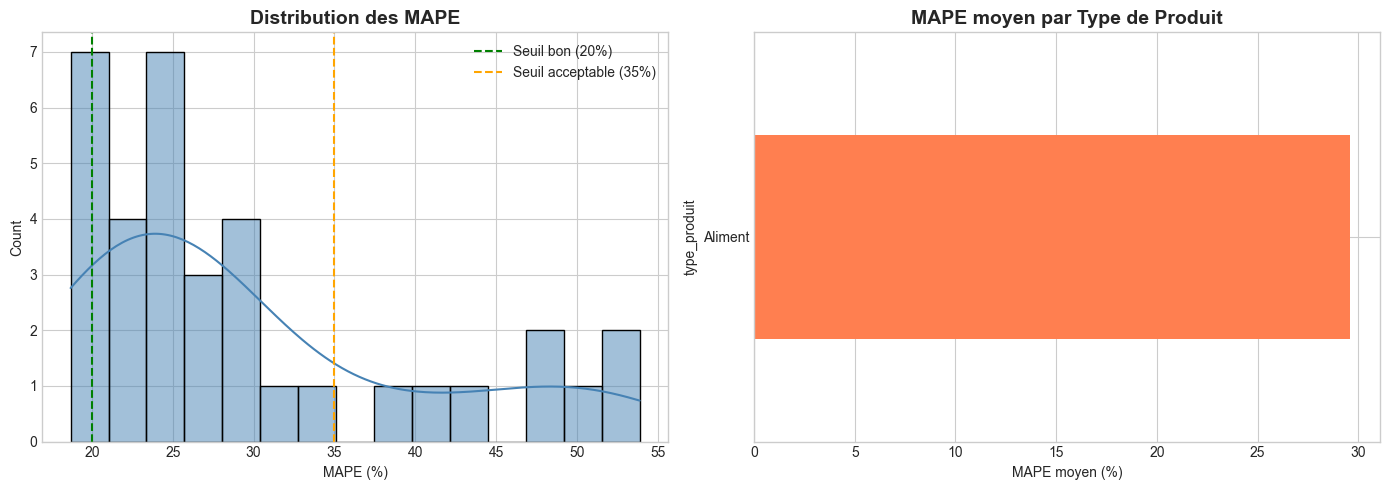

,MAPE_moyen,MAE_moyen,nb_produits
type_produit,,,
Aliment,29.60,3.79,35


In [13]:
# Distribution des MAPE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(metrics_df['MAPE'], bins=15, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(x=20, color='green', linestyle='--', label='Seuil bon (20%)')
axes[0].axvline(x=35, color='orange', linestyle='--', label='Seuil acceptable (35%)')
axes[0].set_title('Distribution des MAPE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('MAPE (%)')
axes[0].legend()

# R² par type de produit
type_perf = metrics_df.groupby('type_produit').agg(
    MAPE_moyen=('MAPE', 'mean'),
    MAE_moyen=('MAE', 'mean'),
    nb_produits=('produit', 'count')
).sort_values('MAPE_moyen')

type_perf['MAPE_moyen'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('MAPE moyen (%)')
axes[1].set_title('MAPE moyen par Type de Produit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

display(type_perf.round(2))

# Étape 6 : Analyse des Coefficients des Régresseurs

 COEFFICIENTS DES RÉGRESSEURS PAR PRODUIT
 Intervalles de confiance calculés via MCMC (300 samples)


regressor,epidemie_grippe,nb_patients,taux_occupation,temperature
produit,,,,
Beurre,1.718900,0.000000,0.102200,0.023600
Biscuits,2.368100,0.009800,0.119600,0.014600
Café,1.821600,0.004500,0.091500,0.023400
Carottes,4.559800,-0.010400,0.240900,-0.018500
Compote de fruits,2.997700,0.011200,0.167500,0.032200
Confiture,1.779100,0.004400,0.084800,-0.005000
Conserves légumes,3.244900,-0.001400,0.218200,0.081600
Crème fraîche,1.971300,0.008000,0.043400,-0.031800
Farine,2.657800,-0.001500,0.174000,0.080800



 INTERVALLES DE CONFIANCE DES COEFFICIENTS
──────────────────────────────────────────────────────────────────────

   temperature:
     Oeufs                 : +0.2848  [-0.0208, +0.5991]  (largeur=0.6200) 
     Lait entier           : +0.2447  [+0.0958, +0.3982]  (largeur=0.3024) ***
     Fruits frais          : +0.1972  [+0.0829, +0.3065]  (largeur=0.2236) ***
     Riz                   : +0.1544  [+0.0939, +0.2104]  (largeur=0.1164) ***
     Pâtes sèches          : +0.1205  [+0.0710, +0.1694]  (largeur=0.0983) ***
     Jus d'orange          : +0.1016  [+0.0399, +0.1609]  (largeur=0.1209) ***
     Conserves légumes     : +0.0816  [+0.0434, +0.1187]  (largeur=0.0753) ***
     Farine                : +0.0808  [+0.0491, +0.1084]  (largeur=0.0593) ***
     Tomates fraîches      : +0.0570  [+0.0040, +0.1081]  (largeur=0.1041) ***
     Pâtes fraîches        : +0.0551  [+0.0169, +0.0934]  (largeur=0.0765) ***
     Huile végétale        : +0.0507  [+0.0312, +0.0689]  (largeur=0.0377) ***
  

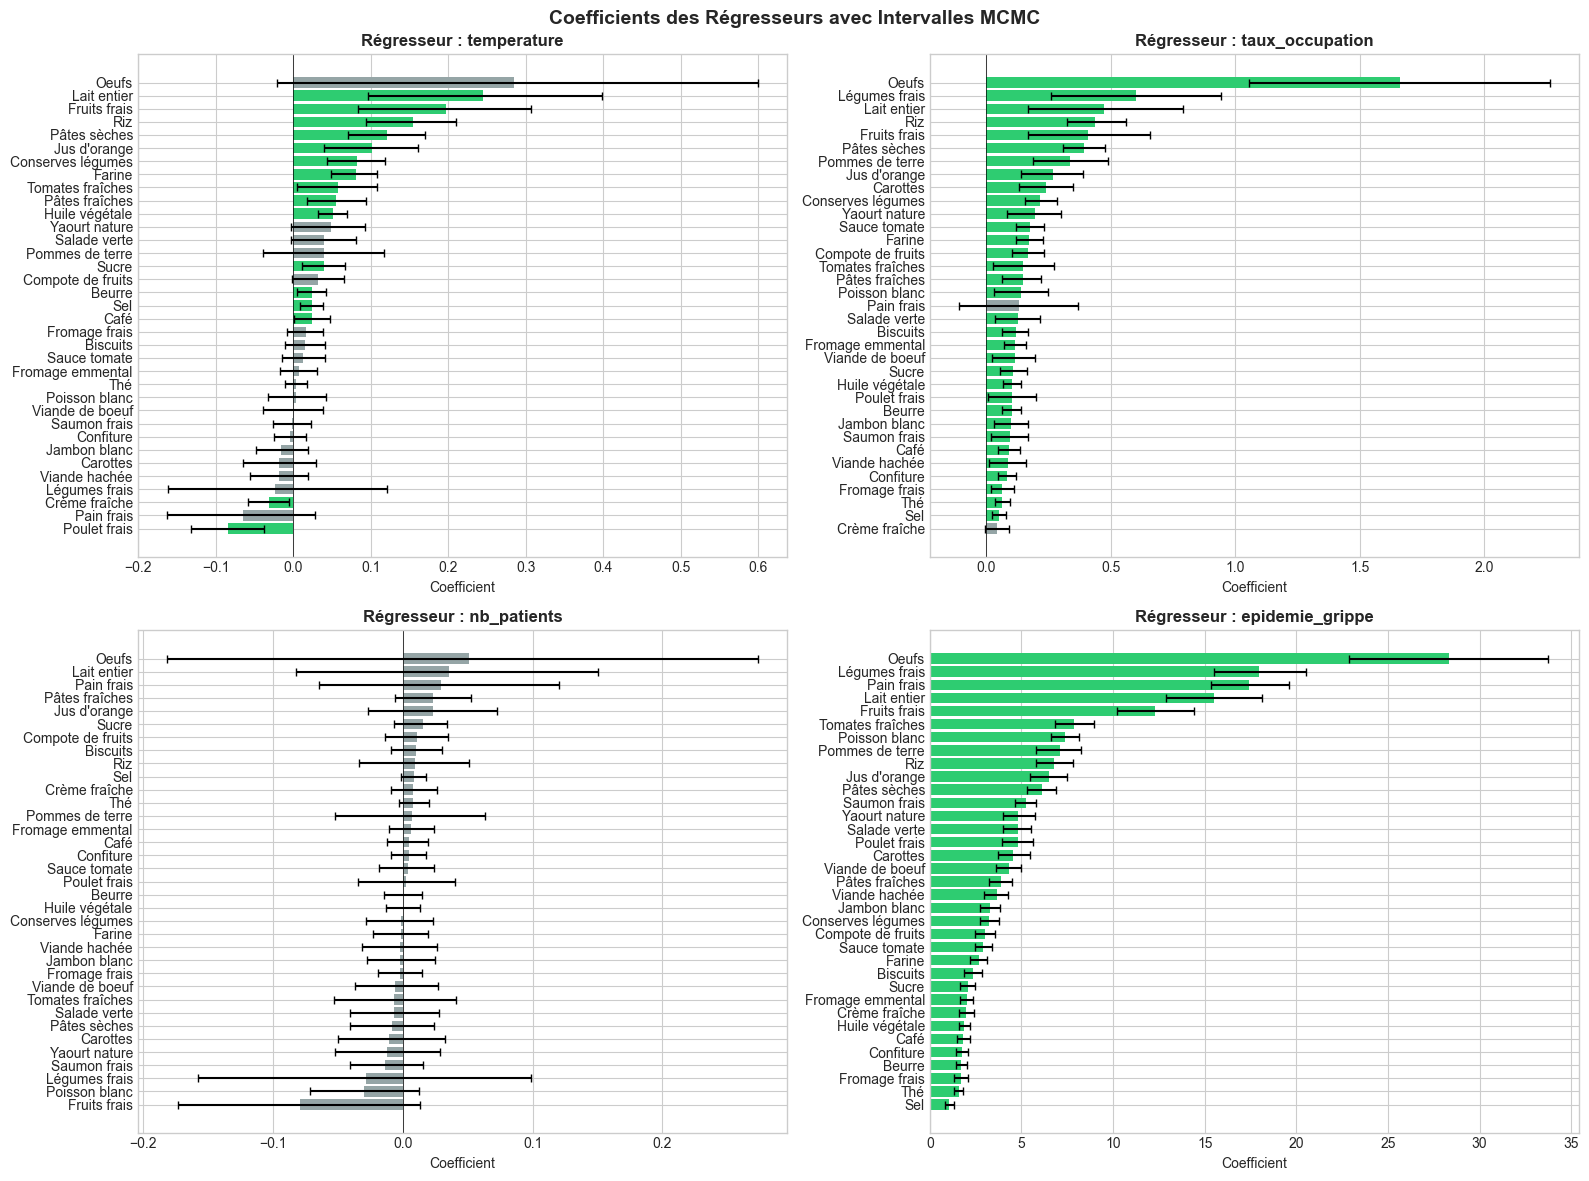


 IMPACT MOYEN DES RÉGRESSEURS
──────────────────────────────────────────────────
   temperature          : +0.0425 → ↑ augmente la consommation  (16/35 significatifs)
   taux_occupation      : +0.2258 → ↑ augmente la consommation  (33/35 significatifs)
   nb_patients          : +0.0015 → ↑ augmente la consommation  (0/35 significatifs)
   epidemie_grippe      : +5.8348 → ↑ augmente la consommation  (35/35 significatifs)


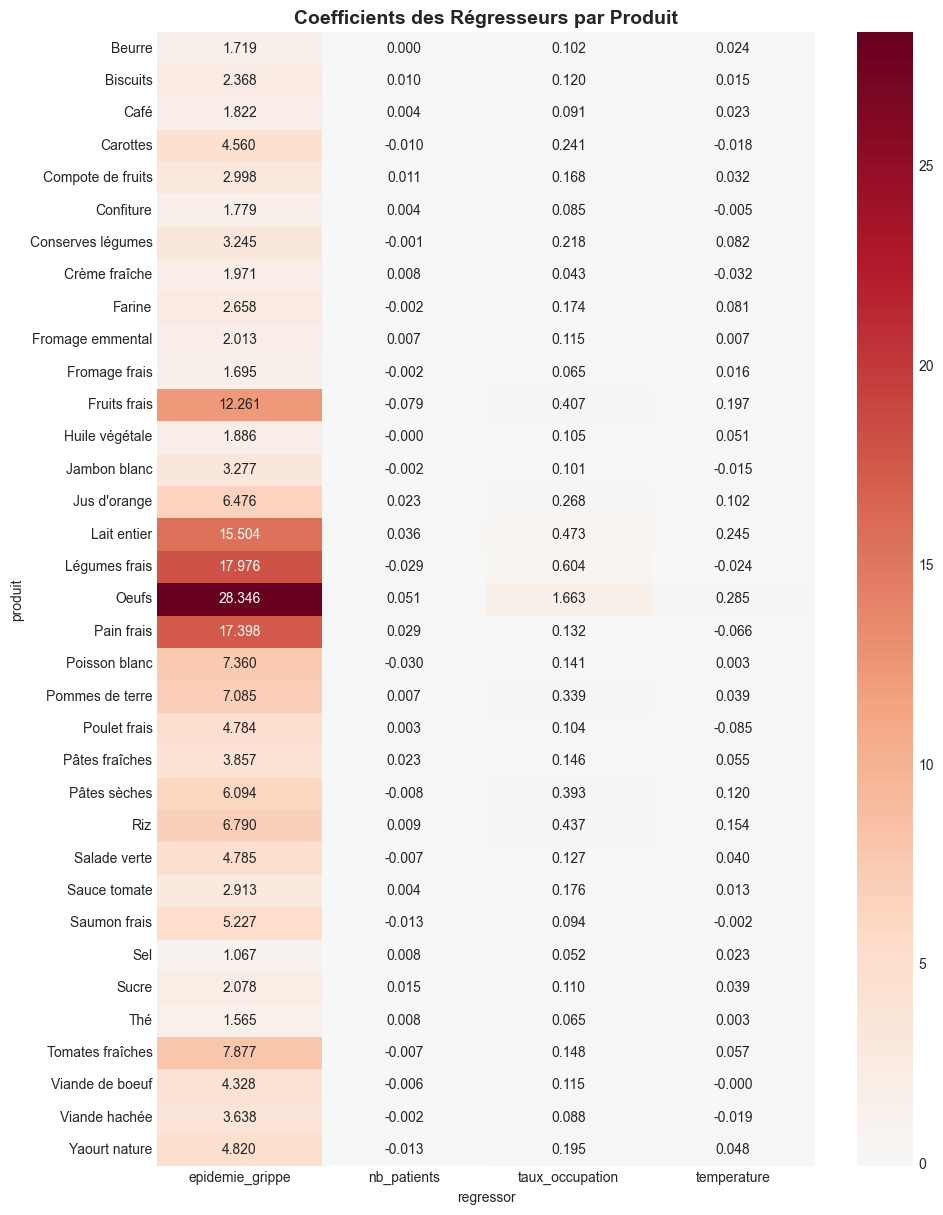

In [14]:
# Coefficients des régresseurs pour tous les produits
if all_coefficients:
    coeffs_df = pd.concat(all_coefficients, ignore_index=True)

    print(" COEFFICIENTS DES RÉGRESSEURS PAR PRODUIT")
    print("="*70)

    has_intervals = MCMC_SAMPLES > 0 and (coeffs_df['coef_lower'] != coeffs_df['coef']).any()

    if has_intervals:
        print(f" Intervalles de confiance calculés via MCMC ({MCMC_SAMPLES} samples)")
    else:
        print(" Estimation MAP uniquement (pas d'intervalles — activer MCMC_SAMPLES > 0)")

    # Tableau pivot : produit × régresseur
    pivot_coeffs = coeffs_df.pivot_table(
        index='produit', columns='regressor', values='coef'
    ).round(4)

    display(pivot_coeffs.style.background_gradient(cmap='RdBu_r', axis=None))

    # Si MCMC : afficher aussi les intervalles
    if has_intervals:
        print("\n INTERVALLES DE CONFIANCE DES COEFFICIENTS")
        print("─"*70)
        for reg in coeffs_df['regressor'].unique():
            subset = coeffs_df[coeffs_df['regressor'] == reg].sort_values('coef', ascending=False)
            print(f"\n   {reg}:")
            for _, row in subset.iterrows():
                width = row['coef_upper'] - row['coef_lower']
                sig = "***" if (row['coef_lower'] > 0 or row['coef_upper'] < 0) else ""
                print(f"     {row['produit']:<22s}: {row['coef']:+.4f}  [{row['coef_lower']:+.4f}, {row['coef_upper']:+.4f}]  (largeur={width:.4f}) {sig}")
        print("\n   *** = intervalle ne contenant pas 0 (effet significatif)")

        # Visualisation : coefficients avec barres d'erreur
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        for ax, reg in zip(axes.ravel(), coeffs_df['regressor'].unique()):
            subset = coeffs_df[coeffs_df['regressor'] == reg].sort_values('coef')
            colors = ['#2ecc71' if (r['coef_lower'] > 0 or r['coef_upper'] < 0) else '#95a5a6'
                       for _, r in subset.iterrows()]
            errors = np.array([
                subset['coef'].values - subset['coef_lower'].values,
                subset['coef_upper'].values - subset['coef'].values
            ])
            ax.barh(subset['produit'], subset['coef'], xerr=errors, color=colors, capsize=3)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
            ax.set_title(f'Régresseur : {reg}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Coefficient')
        plt.suptitle('Coefficients des Régresseurs avec Intervalles MCMC', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Résumé par régresseur
    print("\n IMPACT MOYEN DES RÉGRESSEURS")
    print("─"*50)
    for reg in coeffs_df['regressor'].unique():
        subset = coeffs_df[coeffs_df['regressor'] == reg]
        mean_coeff = subset['coef'].mean()
        effet = '↑ augmente' if mean_coeff > 0 else '↓ diminue'
        if has_intervals:
            nb_sig = ((subset['coef_lower'] > 0) | (subset['coef_upper'] < 0)).sum()
            print(f"   {reg:<20s} : {mean_coeff:+.4f} → {effet} la consommation  ({nb_sig}/{len(subset)} significatifs)")
        else:
            print(f"   {reg:<20s} : {mean_coeff:+.4f} → {effet} la consommation")

    # Heatmap des coefficients
    plt.figure(figsize=(10, max(6, len(pivot_coeffs) * 0.35)))
    sns.heatmap(pivot_coeffs, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
    plt.title('Coefficients des Régresseurs par Produit', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(" Aucun coefficient extrait")

# Étape 7 : Prédictions Futures - Vue Globale

In [15]:
# Consolider toutes les prédictions
predictions_all = pd.concat(all_predictions, ignore_index=True)
predictions_all.columns = ['date', 'quantite_prevue', 'quantite_min', 'quantite_max', 'produit']

print(" PRÉDICTIONS FUTURES - TOUS PRODUITS")
print("="*70)
print(f" {predictions_all['produit'].nunique()} produits | {HORIZON_PREVISION} jours de prédiction")

# Résumé par produit
pred_summary = predictions_all.groupby('produit').agg(
    total_prevu=('quantite_prevue', 'sum'),
    moy_jour=('quantite_prevue', 'mean'),
    min_jour=('quantite_prevue', 'min'),
    max_jour=('quantite_prevue', 'max')
).round(2).sort_values('total_prevu', ascending=False)

display(pred_summary)

print(f"\n TOTAL GLOBAL prévu sur 28 jours : {predictions_all['quantite_prevue'].sum():,.1f}")

 PRÉDICTIONS FUTURES - TOUS PRODUITS
 35 produits | 28 jours de prédiction


,total_prevu,moy_jour,min_jour,max_jour
produit,,,,
Oeufs,2204.74,78.74,53.53,97.72
Lait entier,1074.04,38.36,26.14,48.69
Légumes frais,958.17,34.22,24.88,40.90
Fruits frais,803.72,28.70,20.05,36.25
Pain frais,620.23,22.15,10.90,26.72
Pommes de terre,544.10,19.43,12.89,24.58
Jus d'orange,432.75,15.46,10.81,19.44
Riz,412.48,14.73,10.05,18.19
Poulet frais,395.86,14.14,10.69,16.24



 TOTAL GLOBAL prévu sur 28 jours : 13,551.6


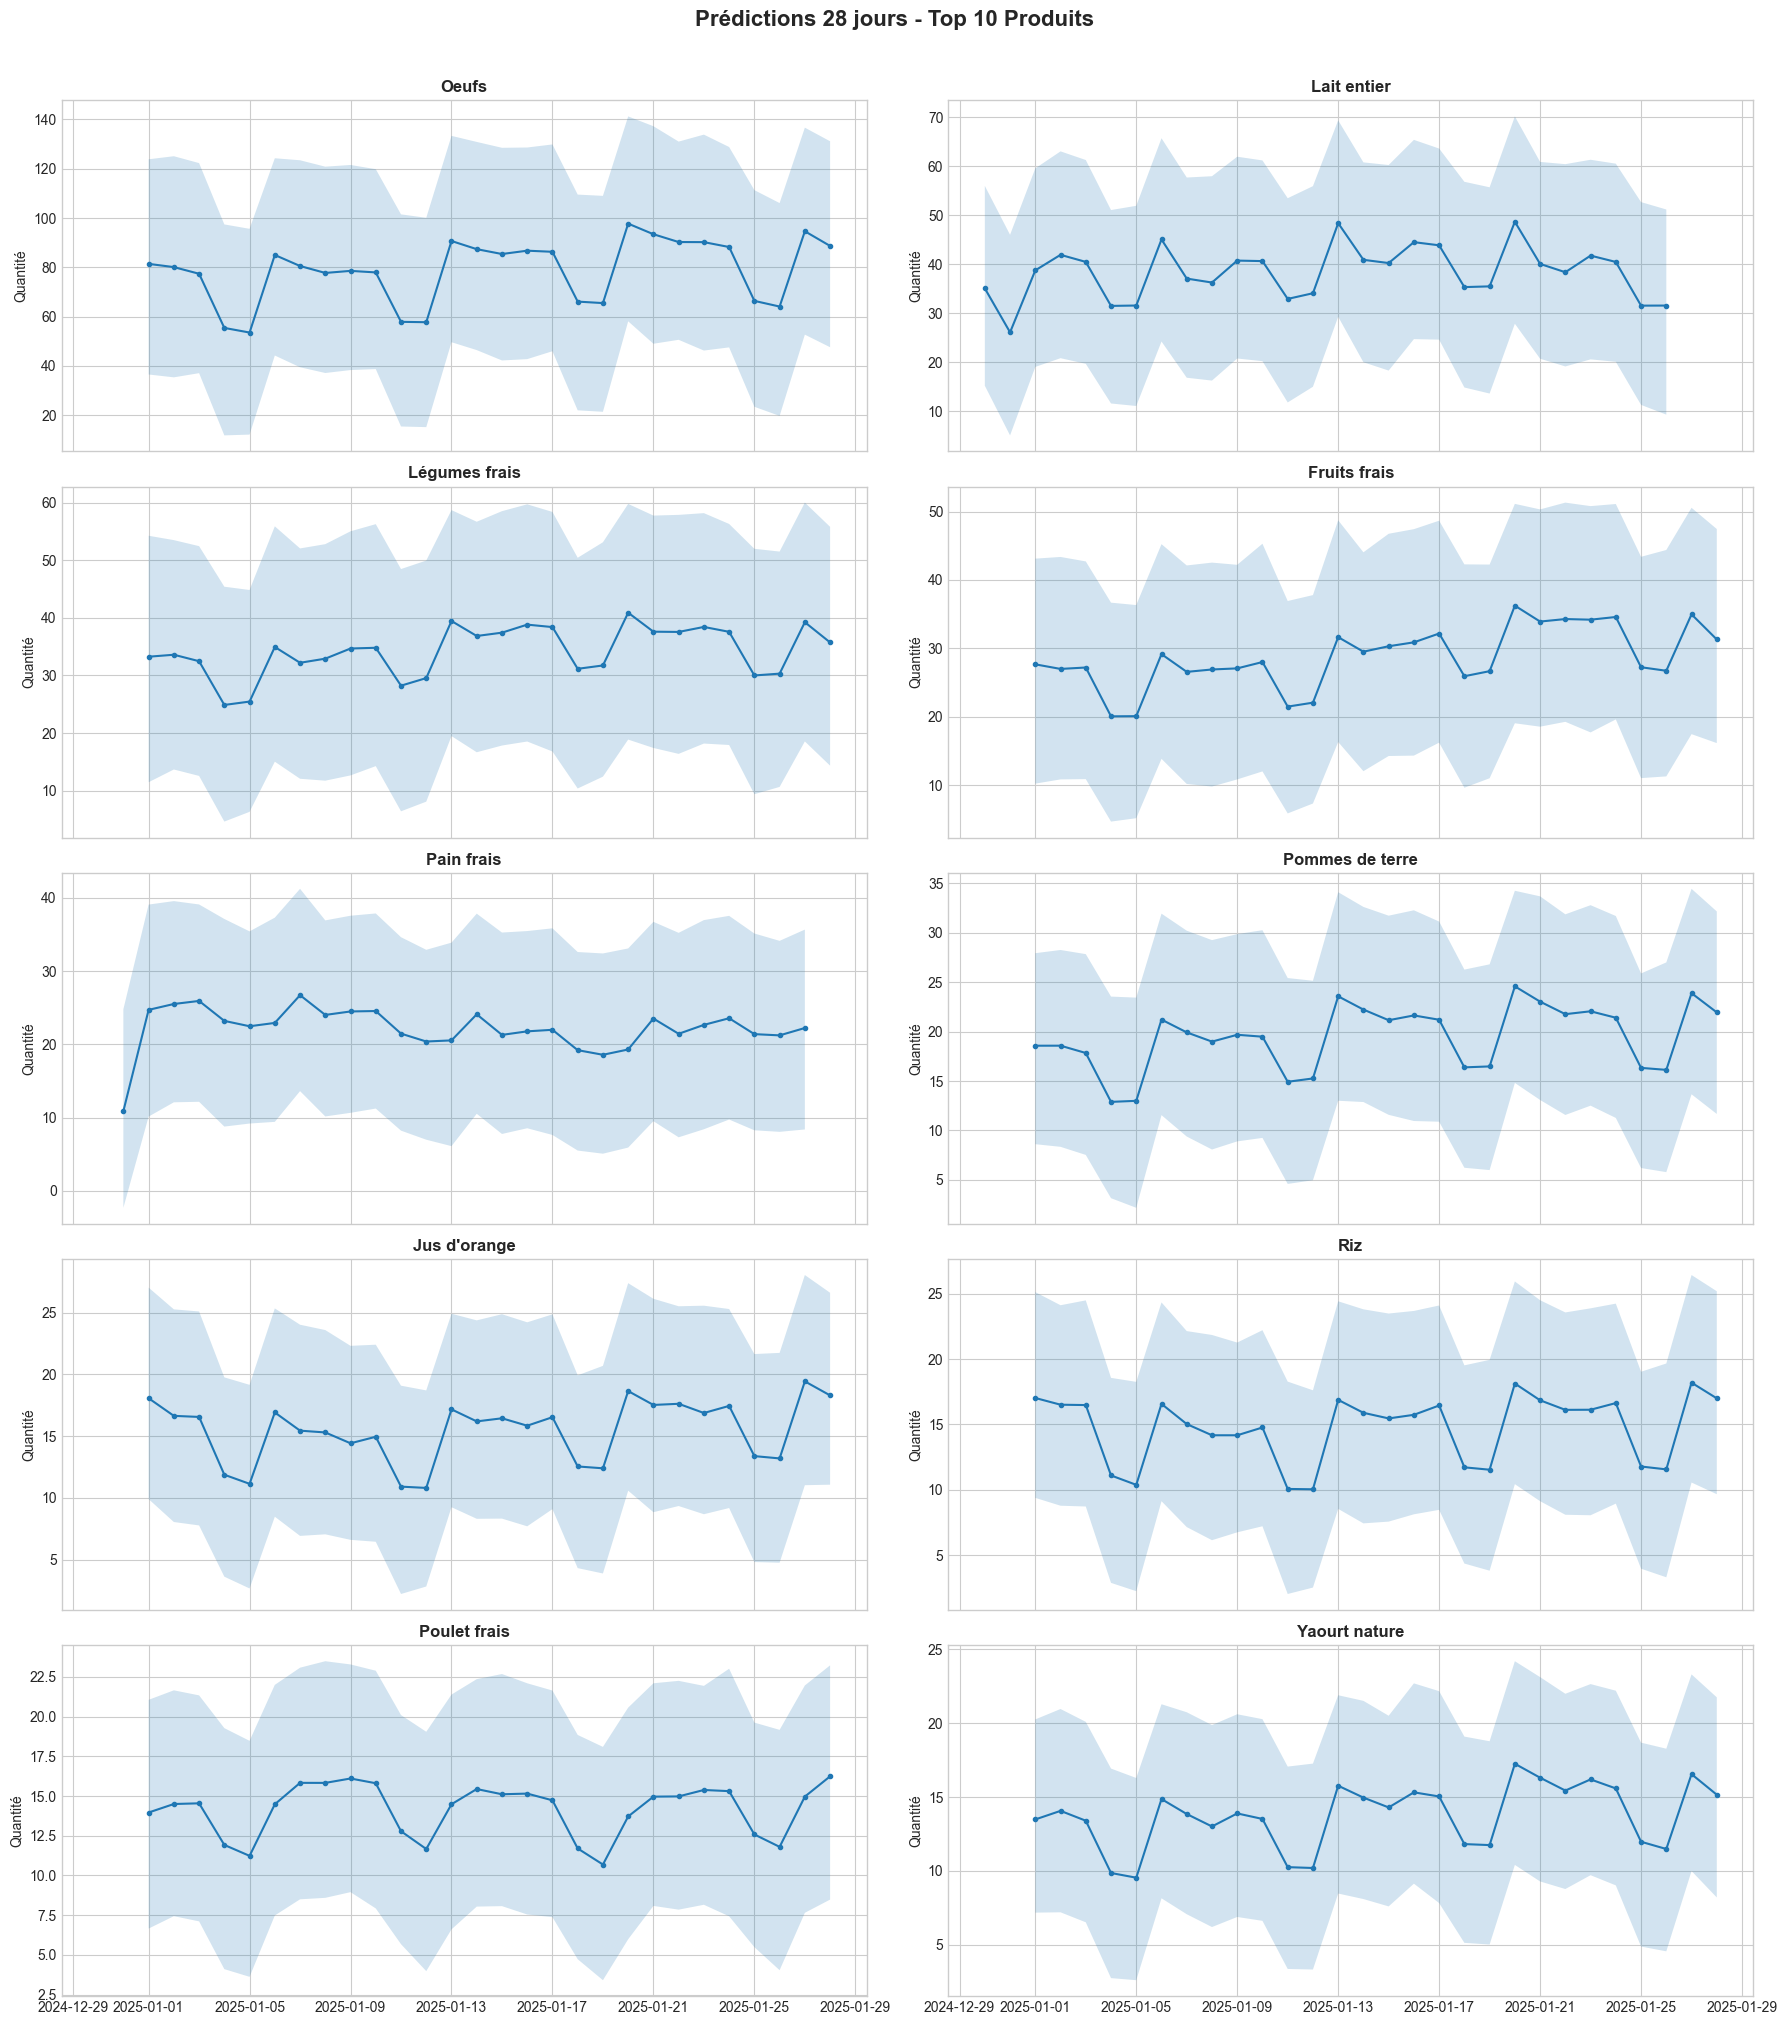

In [16]:
# Top 10 produits : courbes de prédictions futures
top10 = pred_summary.head(10).index.tolist()
preds_top10 = predictions_all[predictions_all['produit'].isin(top10)]

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
for ax, produit in zip(axes.ravel(), top10):
    subset = preds_top10[preds_top10['produit'] == produit]
    ax.plot(subset['date'], subset['quantite_prevue'], marker='o', markersize=3)
    ax.fill_between(subset['date'], subset['quantite_min'], subset['quantite_max'], alpha=0.2)
    ax.set_title(produit, fontweight='bold')
    ax.set_ylabel('Quantité')

plt.suptitle('Prédictions 28 jours - Top 10 Produits', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

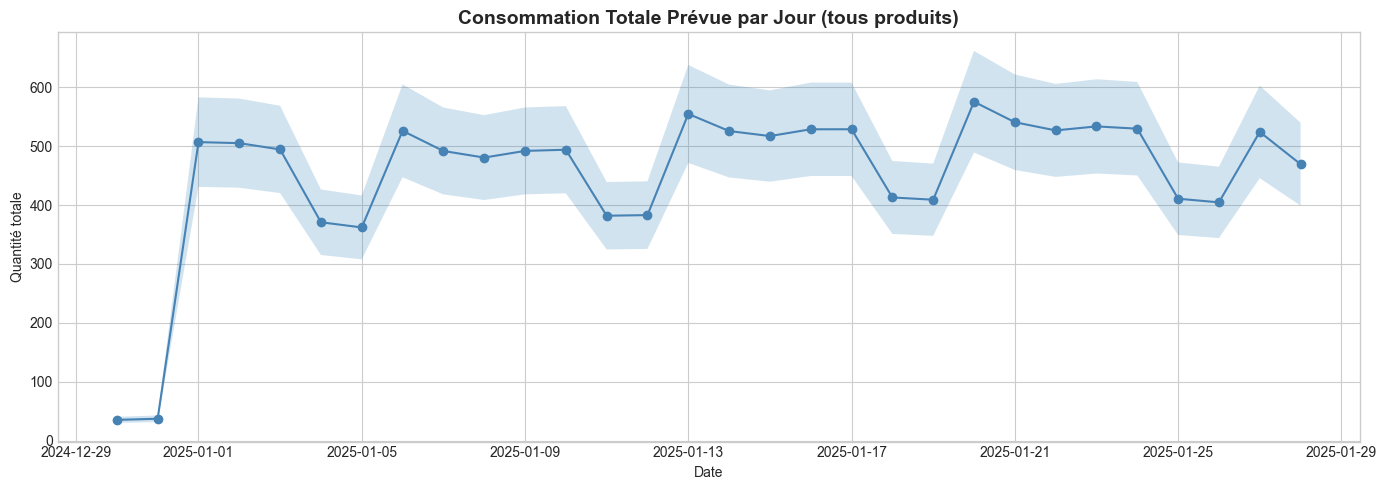

In [17]:
# Consommation totale prévue par jour (tous produits confondus)
total_daily = predictions_all.groupby('date')['quantite_prevue'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(total_daily['date'], total_daily['quantite_prevue'], marker='o', color='steelblue')
plt.fill_between(total_daily['date'], total_daily['quantite_prevue'] * 0.85,
                 total_daily['quantite_prevue'] * 1.15, alpha=0.2)
plt.title('Consommation Totale Prévue par Jour (tous produits)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quantité totale')
plt.tight_layout()
plt.show()

# Étape 8 : Recommandations de Commande

In [18]:
# Tableau des recommandations de commande
reco_df = pd.DataFrame(all_recommendations).sort_values('quantite_a_commander', ascending=False)

print(" RECOMMANDATIONS DE COMMANDE - TOUS PRODUITS")
print("="*70)
print(f" Horizon de commande : {HORIZON_COMMANDE_JOURS} jours")
print(f" Stock de sécurité   : {COUVERTURE_SECURITE_JOURS} jours de consommation moyenne\n")

display(reco_df.style.format({
    'stock_disponible': '{:.1f}',
    'consommation_prevue_7j': '{:.1f}',
    'stock_securite': '{:.1f}',
    'quantite_a_commander': '{:.1f}',
    'qte_arrivages_total_28j': '{:.1f}',
}).background_gradient(subset=['quantite_a_commander'], cmap='Reds'))

print(f"\n TOTAL à commander (7j) : {reco_df['quantite_a_commander'].sum():,.1f}")
print(f" Produits nécessitant une commande : {(reco_df['quantite_a_commander'] > 0).sum()}/{len(reco_df)}")

 RECOMMANDATIONS DE COMMANDE - TOUS PRODUITS
 Horizon de commande : 7 jours
 Stock de sécurité   : 2 jours de consommation moyenne



,produit,stock_disponible,consommation_prevue_7j,stock_securite,quantite_a_commander,couverture_estimee_jours,dlc_jours,nb_arrivages_28j,qte_arrivages_total_28j
17,Oeufs,280.1,513.3,146.7,379.9,3.800000,18,2,1924.7
15,Lait entier,52.7,245.6,70.2,263.0,1.500000,3,10,1021.3
18,Pain frais,8.5,155.7,44.5,191.6,0.400000,1,28,611.7
16,Légumes frais,91.0,216.8,62.0,187.7,2.900000,10,3,867.1
11,Fruits frais,92.2,177.7,50.8,136.3,3.600000,7,4,711.5
21,Poulet frais,16.5,96.5,27.6,107.5,1.200000,2,14,381.9
20,Pommes de terre,65.1,122.0,34.9,91.8,3.700000,17,2,479.0
31,Tomates fraîches,15.5,83.0,23.7,91.2,1.300000,2,14,328.6
32,Viande de boeuf,24.5,81.6,23.3,80.4,2.100000,2,14,303.6
19,Poisson blanc,9.9,64.7,18.5,73.2,1.100000,1,28,241.7



 TOTAL à commander (7j) : 2,083.3
 Produits nécessitant une commande : 20/35


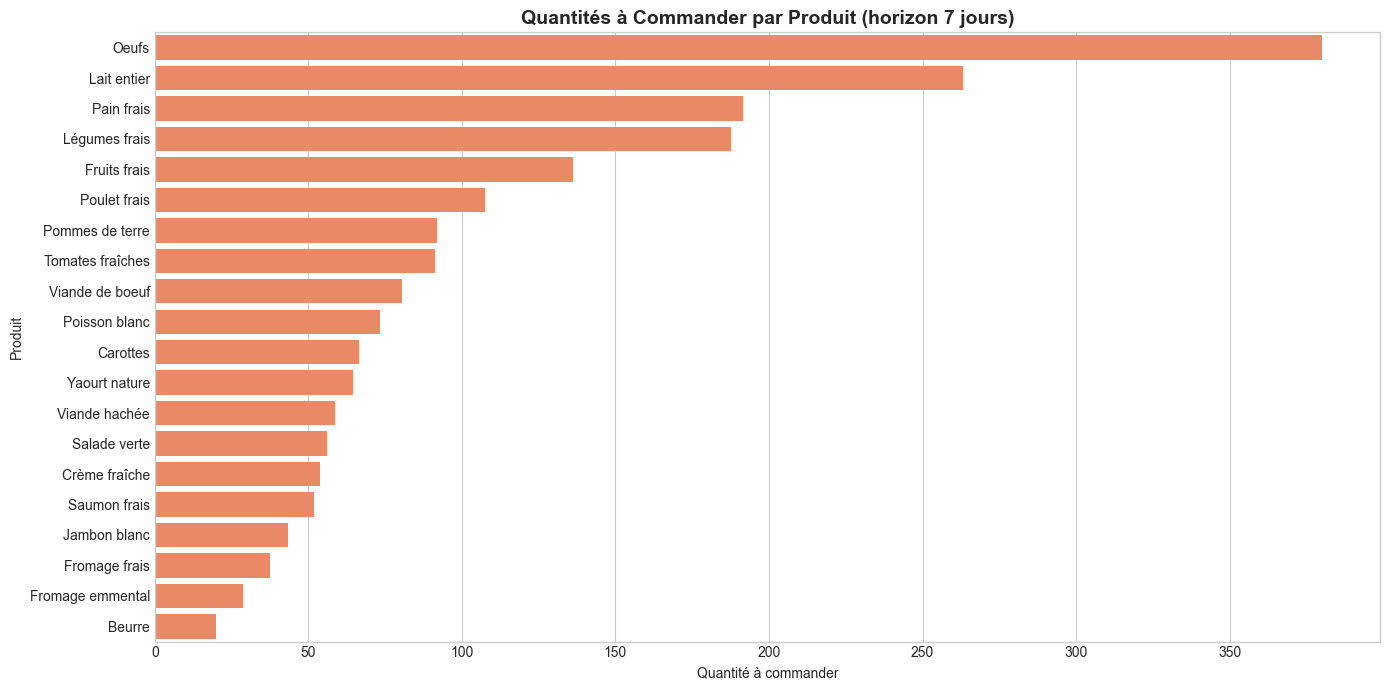

In [19]:
# Visualisation des quantités à commander
reco_nonzero = reco_df[reco_df['quantite_a_commander'] > 0].copy()

if not reco_nonzero.empty:
    plt.figure(figsize=(14, max(6, len(reco_nonzero) * 0.35)))
    sns.barplot(data=reco_nonzero, x='quantite_a_commander', y='produit', color='coral')
    plt.title('Quantités à Commander par Produit (horizon 7 jours)', fontsize=14, fontweight='bold')
    plt.xlabel('Quantité à commander')
    plt.ylabel('Produit')
    plt.tight_layout()
    plt.show()
else:
    print(" Aucun produit ne nécessite de commande immédiate")

# Étape 9 : Plans d'Arrivages Consolidés

In [20]:
# Consolider tous les plans d'arrivages
if all_arrivages:
    arrivages_all = pd.concat(all_arrivages, ignore_index=True)

    # Convertir les dates
    for col in ['arrival_date', 'coverage_start', 'coverage_end']:
        arrivages_all[col] = pd.to_datetime(arrivages_all[col]).dt.date

    numeric_cols = ['predicted_consumption_window', 'current_stock_used',
                    'quantity_to_order', 'remaining_current_stock']
    arrivages_all[numeric_cols] = arrivages_all[numeric_cols].round(2)

    print(" PLANS D'ARRIVAGES - TOUS PRODUITS")
    print("="*70)
    print(f" {arrivages_all['produit'].nunique()} produits avec arrivages planifiés")
    print(f" {len(arrivages_all)} arrivages au total")
    print(f" Quantité totale à commander : {arrivages_all['quantity_to_order'].sum():,.1f}\n")

    # Résumé par produit
    arrivages_summary = arrivages_all.groupby('produit').agg(
        nb_arrivages=('produit', 'size'),
        qte_totale=('quantity_to_order', 'sum'),
        premier_arrivage=('arrival_date', 'min'),
        dernier_arrivage=('arrival_date', 'max')
    ).sort_values('qte_totale', ascending=False).round(2)

    display(arrivages_summary)
else:
    print(" Aucun plan d'arrivages généré")

 PLANS D'ARRIVAGES - TOUS PRODUITS
 35 produits avec arrivages planifiés
 256 arrivages au total
 Quantité totale à commander : 11,313.3



,nb_arrivages,qte_totale,premier_arrivage,dernier_arrivage
produit,,,,
Oeufs,2,1924.70,2025-01-01,2025-01-19
Lait entier,10,1021.31,2024-12-30,2025-01-26
Légumes frais,3,867.15,2025-01-01,2025-01-21
Fruits frais,4,711.53,2025-01-01,2025-01-22
Pain frais,28,611.71,2024-12-31,2025-01-27
Pommes de terre,2,479.03,2025-01-01,2025-01-18
Poulet frais,14,381.88,2025-01-01,2025-01-27
Yaourt nature,4,334.74,2025-01-01,2025-01-22
Tomates fraîches,14,328.57,2025-01-01,2025-01-27


# Étape 10 : Export des Résultats Consolidés

In [21]:
# Créer le dossier de résultats
date_analyse = datetime.now().strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = Path(f"../results/analyse-tous_produits-{date_analyse}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f" Dossier de résultats : {RESULTS_DIR}")

# 1. CSV des métriques
metrics_path = RESULTS_DIR / 'metrics_tous_produits.csv'
metrics_df.to_csv(metrics_path, index=False, encoding='utf-8')
print(f" Métriques exportées : {metrics_path.name}")

# 2. CSV des prédictions
predictions_path = RESULTS_DIR / 'predictions_tous_produits_28j.csv'
predictions_export = predictions_all.copy()
predictions_export['date'] = pd.to_datetime(predictions_export['date']).dt.date
predictions_export['confiance'] = '85%'
predictions_export = predictions_export[['date', 'produit', 'quantite_prevue', 'quantite_min', 'quantite_max', 'confiance']]
predictions_export.to_csv(predictions_path, index=False, encoding='utf-8')
print(f" Prédictions exportées : {predictions_path.name}")

# 3. CSV des recommandations
reco_path = RESULTS_DIR / 'recommandations_commande.csv'
reco_df.to_csv(reco_path, index=False, encoding='utf-8')
print(f" Recommandations exportées : {reco_path.name}")

# 4. CSV des arrivages
if all_arrivages:
    arrivages_path = RESULTS_DIR / 'arrivages_tous_produits_28j.csv'
    arrivages_all.to_csv(arrivages_path, index=False, encoding='utf-8')
    print(f" Arrivages exportés : {arrivages_path.name}")

# 5. CSV des coefficients
if all_coefficients:
    coeffs_path = RESULTS_DIR / 'coefficients_regresseurs.csv'
    coeffs_df.to_csv(coeffs_path, index=False, encoding='utf-8')
    print(f" Coefficients exportés : {coeffs_path.name}")

 Dossier de résultats : ..\results\analyse-tous_produits-20260315_165036
 Métriques exportées : metrics_tous_produits.csv
 Prédictions exportées : predictions_tous_produits_28j.csv
 Recommandations exportées : recommandations_commande.csv
 Arrivages exportés : arrivages_tous_produits_28j.csv
 Coefficients exportés : coefficients_regresseurs.csv


In [22]:
# Sauvegarder les graphiques par produit (prédictions Prophet)
print("\n EXPORT DES GRAPHIQUES (1 par produit)")
print("="*70)

graphs_dir = RESULTS_DIR / 'graphiques'
graphs_dir.mkdir(exist_ok=True)

for produit_name, model_f in product_models.items():
    produit_slug = produit_name.lower().replace(' ', '_').replace('é', 'e').replace('è', 'e').replace('ê', 'e').replace('î', 'i').replace('ô', 'o')
    forecast_f = product_forecasts[produit_name]

    # Prédictions principales
    fig = model_f.plot(forecast_f)
    plt.title(f'Prédictions Prophet - {produit_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Consommation')
    plt.tight_layout()
    plt.savefig(graphs_dir / f'predictions_{produit_slug}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f" {len(product_models)} graphiques sauvegardés dans {graphs_dir}")


 EXPORT DES GRAPHIQUES (1 par produit)
 35 graphiques sauvegardés dans ..\results\analyse-tous_produits-20260315_165036\graphiques


In [23]:
# Export JSON du résumé global
summary_global = {
    "date_analyse": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "dossier_resultats": str(RESULTS_DIR),
    "dataset": {
        "fichier": "dataset_stock_hopital_ENRICHI.csv",
        "version": "3.0",
        "nb_lignes_total": int(len(df)),
        "nb_produits_total": int(df['nom_produit'].nunique()),
        "periode": f"{df['date'].min().date()} → {df['date'].max().date()}"
    },
    "analyse": {
        "nb_produits_analyses": len(all_metrics),
        "nb_produits_ignores": len(skipped_products),
        "produits_ignores": skipped_products,
        "horizon_prevision_jours": HORIZON_PREVISION,
        "horizon_commande_jours": HORIZON_COMMANDE_JOURS,
        "couverture_securite_jours": COUVERTURE_SECURITE_JOURS,
    },
    "performance_globale": {
        "MAPE_moyen": round(metrics_df['MAPE'].mean(), 2),
        "MAPE_median": round(metrics_df['MAPE'].median(), 2),
        "MAE_moyen": round(metrics_df['MAE'].mean(), 2),
        "meilleur_produit": metrics_df.iloc[0]['produit'],
        "meilleur_MAPE": round(metrics_df.iloc[0]['MAPE'], 2),
        "pire_produit": metrics_df.iloc[-1]['produit'],
        "pire_MAPE": round(metrics_df.iloc[-1]['MAPE'], 2),
        "nb_produits_MAPE_inf_20": int((metrics_df['MAPE'] < 20).sum()),
        "nb_produits_MAPE_inf_35": int((metrics_df['MAPE'] < 35).sum()),
    },
    "configuration_modele": {
        "methode": "Prophet avec regressors enrichis",
        "holidays": ["jour_ferie", "covid_19"],
        "changepoints_manuels": changepoints_manuels,
        "regresseurs": ["temperature", "taux_occupation", "nb_patients", "epidemie_grippe"],
        "seasonality": {"yearly": 20, "weekly": 5, "mode": "multiplicative"},
        "mcmc_samples": MCMC_SAMPLES,
        "inference": "MCMC (NUTS)" if MCMC_SAMPLES > 0 else "MAP",
    },
    "commandes": {
        "total_a_commander_7j": round(reco_df['quantite_a_commander'].sum(), 2),
        "nb_produits_a_commander": int((reco_df['quantite_a_commander'] > 0).sum()),
    },
    "produits": [
        {**m, **r}
        for m, r in zip(all_metrics, all_recommendations)
    ],
    "fichiers_generes": [
        str(p.relative_to(RESULTS_DIR)) for p in sorted(RESULTS_DIR.rglob('*')) if p.is_file()
    ]
}

summary_path = RESULTS_DIR / 'summary_tous_produits.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_global, f, indent=2, ensure_ascii=False, default=str)

print(f" Résumé JSON exporté : {summary_path.name}")

 Résumé JSON exporté : summary_tous_produits.json


In [24]:
# Créer un README dans le dossier de résultats
readme_content = f"""# Résultats d'Analyse Multi-Produits

**Date d'analyse** : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Produits analysés** : {len(all_metrics)}
**Dataset** : Enrichi v3.0 ({len(df):,} lignes)

---

## Performance Globale

| Indicateur | Valeur |
|------------|--------|
| MAPE moyen | {metrics_df['MAPE'].mean():.1f}% |
| MAPE médian | {metrics_df['MAPE'].median():.1f}% |
| Meilleur produit | {metrics_df.iloc[0]['produit']} ({metrics_df.iloc[0]['MAPE']:.1f}%) |
| Pire produit | {metrics_df.iloc[-1]['produit']} ({metrics_df.iloc[-1]['MAPE']:.1f}%) |
| Produits < 20% MAPE | {(metrics_df['MAPE'] < 20).sum()}/{len(metrics_df)} |

## Commandes

- **Total à commander (7j)** : {reco_df['quantite_a_commander'].sum():,.1f}
- **Produits nécessitant commande** : {(reco_df['quantite_a_commander'] > 0).sum()}/{len(reco_df)}

## Fichiers Générés

- `metrics_tous_produits.csv` - Métriques de performance par produit
- `predictions_tous_produits_28j.csv` - Prédictions 28 jours par produit
- `recommandations_commande.csv` - Recommandations de commande par produit
- `arrivages_tous_produits_28j.csv` - Plans d'arrivages par produit
- `coefficients_regresseurs.csv` - Coefficients des régresseurs par produit
- `graphiques/` - Graphiques de prédictions par produit
- `summary_tous_produits.json` - Résumé complet en JSON

---

*Généré par le notebook Analyse_Tous_Produits_ENRICHI*
"""

readme_path = RESULTS_DIR / 'README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f" README créé : {readme_path.name}")

 README créé : README.md


# Étape 11 : Synthèse Finale

In [25]:
# Résumé final
print("\n" + "="*70)
print(" ANALYSE MULTI-PRODUITS TERMINÉE !")
print("="*70)

print(f"\n RÉSUMÉ")
print(f"   Dataset             : Enrichi v3.0 ({len(df):,} lignes)")
print(f"   Produits analysés   : {len(all_metrics)}")
print(f"   Produits ignorés    : {len(skipped_products)}")
print(f"   Modèle              : Prophet + 4 régresseurs")

print(f"\n PERFORMANCE")
print(f"   MAPE moyen          : {metrics_df['MAPE'].mean():.1f}%")
print(f"   MAPE médian         : {metrics_df['MAPE'].median():.1f}%")
print(f"   Produits < 20% MAPE : {(metrics_df['MAPE'] < 20).sum()}/{len(metrics_df)}")
print(f"   Produits < 35% MAPE : {(metrics_df['MAPE'] < 35).sum()}/{len(metrics_df)}")

print(f"\n PRÉDICTIONS")
print(f"   Horizon             : {HORIZON_PREVISION} jours")
print(f"   Total prévu (28j)   : {predictions_all['quantite_prevue'].sum():,.1f}")

print(f"\n COMMANDES")
print(f"   Horizon commande    : {HORIZON_COMMANDE_JOURS} jours")
print(f"   Total à commander   : {reco_df['quantite_a_commander'].sum():,.1f}")
print(f"   Produits à commander: {(reco_df['quantite_a_commander'] > 0).sum()}/{len(reco_df)}")

if all_arrivages:
    print(f"\n ARRIVAGES")
    print(f"   Total arrivages     : {len(arrivages_all)}")
    print(f"   Qté totale 28j      : {arrivages_all['quantity_to_order'].sum():,.1f}")

print(f"\n RÉSULTATS DANS :")
print(f"   {RESULTS_DIR}")

if MLFLOW_AVAILABLE:
    print(f"\n MLFLOW")
    print(f"   Tracking URI        : {MLFLOW_TRACKING_URI}")
    print(f"   Expérience          : {MLFLOW_EXPERIMENT}")

print("\n" + "="*70)
print(" Notebook terminé ! Tous les produits ont été analysés.")
print("="*70)


 ANALYSE MULTI-PRODUITS TERMINÉE !

 RÉSUMÉ
   Dataset             : Enrichi v3.0 (76,539 lignes)
   Produits analysés   : 35
   Produits ignorés    : 0
   Modèle              : Prophet + 4 régresseurs

 PERFORMANCE
   MAPE moyen          : 29.6%
   MAPE médian         : 25.5%
   Produits < 20% MAPE : 6/35
   Produits < 35% MAPE : 27/35

 PRÉDICTIONS
   Horizon             : 28 jours
   Total prévu (28j)   : 13,551.6

 COMMANDES
   Horizon commande    : 7 jours
   Total à commander   : 2,083.3
   Produits à commander: 20/35

 ARRIVAGES
   Total arrivages     : 256
   Qté totale 28j      : 11,313.3

 RÉSULTATS DANS :
   ..\results\analyse-tous_produits-20260315_165036

 MLFLOW
   Tracking URI        : sqlite:///C:/Users/mxmle/project/final-project/mlflow.db
   Expérience          : prophet-notebook-enrichi

 Notebook terminé ! Tous les produits ont été analysés.
